In [55]:
%pip install japanize_matplotlib








771642.80s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 必要ライブラリの準備
import os
import math
import gzip
from time import sleep
from random import gauss

from itertools import product
import pickle
from datetime import datetime, timedelta, date
from urllib import request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント対応

%matplotlib inline

warnings.simplefilter('ignore')

In [59]:
import japanize_matplotlib 

In [32]:
import matplotlib.pyplot as plt

In [33]:
exec_data = pd.read_pickle('/Users/kanekokyuutarou/Desktop/bybit_BTCUSD_2022_3.pkl')

In [34]:
exec_data.columns





Index(['timestamp', 'symbol', 'side', 'size', 'price', 'tickDirection',
       'trdMatchID', 'grossValue', 'homeNotional', 'foreignNotional'],
      dtype='object')

In [35]:
exec_data["timestamp"] = pd.to_datetime(exec_data["timestamp"], unit="s")
exec_data.set_index("timestamp", inplace=True)
exec_data.head()

,symbol,side,size,price,tickDirection,trdMatchID,grossValue,homeNotional,foreignNotional
timestamp,,,,,,,,,
2022-03-01,BTCUSD,Sell,9,43179.5,MinusTick,876d94ec-9f6a-528f-9648-55c6133e19d6,20843.224215,9,0.000208
2022-03-01,BTCUSD,Sell,3,43179.5,ZeroMinusTick,b94b11dc-7747-50c5-9590-a732ab859939,6947.741405,3,0.000069
2022-03-01,BTCUSD,Sell,2,43179.5,ZeroMinusTick,2c833623-2598-57fa-8408-92900ffdc90f,4631.827603,2,0.000046
2022-03-01,BTCUSD,Sell,1,43178.5,MinusTick,ce18bf17-3535-534d-8745-bafb1267de27,2315.967437,1,0.000023
2022-03-01,BTCUSD,Sell,1,43178.0,MinusTick,29f8b6bf-066f-59c2-83b5-fe63a3739954,2315.994256,1,0.000023


In [36]:
len(exec_data)

11921083

In [37]:
#　サンプリング期間 15分間隔のタイムバーを作成
FREQ = "15min"
# ohlcvの列を持ったテーブルデータ他形式のバーも同様の列を持つ
time_bar = pd.DataFrame(columns=["op", "hi", "lo", "cl", "volume"])
time_bar.index.name = "timestamp"

ohlc = exec_data["price"].resample(FREQ).ohlc()
volume = exec_data["size"].resample(FREQ).sum()
ohlcv = pd.concat([ohlc, volume], axis=1)
ohlcv.index.name = "timestamp"
ohlcv.columns = ["op", "hi", "lo", "cl", "volume"]

time_bar = pd.concat([time_bar, ohlcv], axis=0)

time_bar.head()

,op,hi,lo,cl,volume
timestamp,,,,,
2022-03-01 00:00:00,43179.5,43593.0,43177.0,43367.0,39018957
2022-03-01 00:15:00,43367.0,43384.0,43198.5,43367.0,9372331
2022-03-01 00:30:00,43367.5,43541.5,43318.5,43524.5,22522912
2022-03-01 00:45:00,43524.5,43745.0,43341.5,43549.5,27202334
2022-03-01 01:00:00,43549.5,43620.0,43279.0,43294.0,13692174


Text(0.5, 1.0, 'タイムバー')

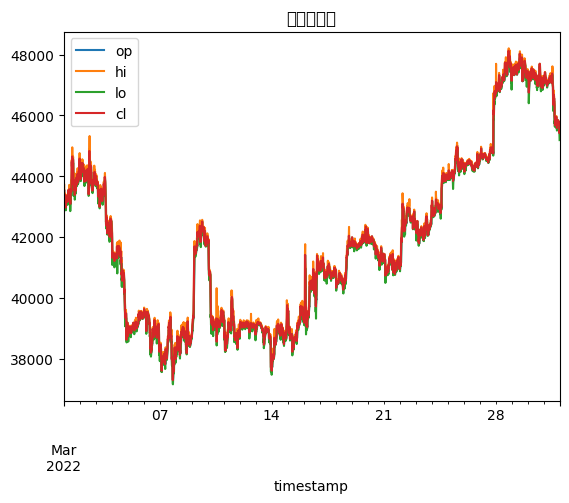

In [38]:
time_bar[["op","hi","lo","cl"]].plot()
plt.title("タイムバー")

<Axes: title={'center': 'リターンのヒストグラム'}>

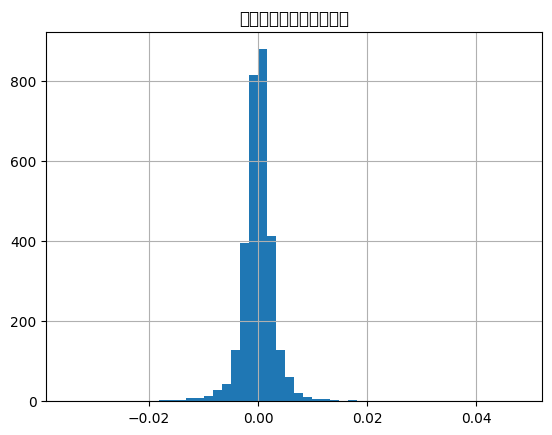

In [39]:
plt.title("リターンのヒストグラム")
time_bar["cl"].pct_change().hist(bins=50)

In [40]:
del exec_data

In [41]:
df = time_bar.copy()
# 対数処理
df["log_open"] = np.log(df["op"])
df["log_high"] = np.log(df["hi"])
df["log_low"] = np.log(df["lo"])
df["log_close"] = np.log(df["cl"])
# 対数差分処理
df["diff_log_open"] = df["log_open"].diff()
df["diff_log_high"] = df["log_high"].diff()
df["diff_log_low"] = df["log_low"].diff()
df["diff_log_close"] = df["log_close"].diff()
df["diff_volume"] = df["volume"].diff()
df.dropna(inplace=True)

<Axes: title={'center': '終値価格リターン系列'}, xlabel='timestamp', ylabel='diff_log_close'>

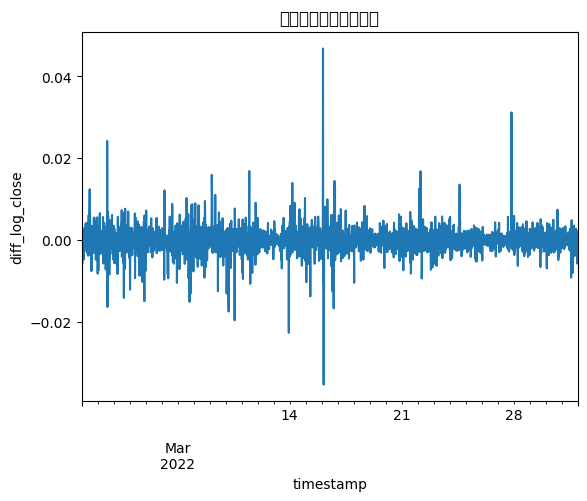

In [42]:
# 終値価格リターン系列を確認
plt.title("終値価格リターン系列")
plt.ylabel("diff_log_close")
df["diff_log_close"].plot()

In [43]:
# 関数の用意

# 可視化のための関数
def plot_result(target, pred, title, ylabel):
    plt.figure(figsize=(15,5))
    plt.plot(target.index, target, c='blue', label='実際', marker='.')
    plt.plot(target.index, pred, c='r', label='予測値', marker='.')
    plt.ylabel(ylabel, fontsize=17)
    plt.legend()
    plt.title(title)
    plt.show()

# 残差の可視化のための関数
def plot_resid(target, pred, title, ylabel):
    plt.figure(figsize=(15,5))
    plt.plot(target.index, target-pred, c='green', marker='.')
    plt.ylabel(ylabel, fontsize=17)
    plt.title(title)
    plt.show()

# train validationの分割のための関数
def timeseries_train_val_split(Xy, target="y"):
    # 時系列の前半75%を学習, 後半25%を検証に利用する
    train, val = Xy[:int(len(Xy)*0.75)], Xy[int(len(Xy)*0.75)+10:]
    trainX = train.drop([target],axis=1)
    trainy = train[target]
    valX = val.drop([target],axis=1)
    valy = val[target]
    return trainX, trainy, valX, valy

from sklearn.metrics import accuracy_score
# 上昇もしくは下落の予測のaccuracyを測定する関数
def eval_direction(target, pred):
    target = np.where(np.array(target) > 0, 1, -1)
    pred = np.where(np.array(pred) > 0, 1, -1)
    print("accuracy", accuracy_score(target, pred))

In [45]:
# ADF検定用パッケージ
from statsmodels.tsa.stattools import adfuller

In [46]:
def adf_test(data, sig_level = 0.05, do_print=True) -> bool:
    """
    ADF検定を実施する関数
    Args:
        data: 検定対象の系列データ
        sig_level: 有意水準
        do_print: 検定結果をprintするかどうか
    Returns:
        bool: Trueの場合定常,Falseの場合非定常を表す
    """
    if do_print:
        print('Results of Dickey-Fuller Examination:')
    dftest = adfuller(data)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    if do_print:
        print(dfoutput)
    return dfoutput['p-value'] < sig_level
    

Results of Dickey-Fuller Examination:
Test Statistic                   -1.056981
p-value                           0.731919
#Lags Used                        4.000000
Number of Observations Used    2970.000000
dtype: float64
対数価格系列は非定常である


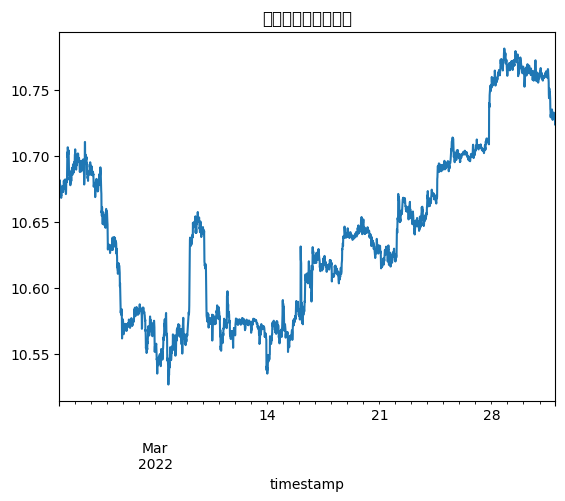

In [47]:
plt.title("終値の対数価格系列")
df["log_close"].plot()

if adf_test(df["log_close"], do_print=True):
    print("対数価格系列は定常である")
else:
    print("対数価格系列は非定常である")

Results of Dickey-Fuller Examination:
Test Statistic                  -27.754658
p-value                           0.000000
#Lags Used                        3.000000
Number of Observations Used    2971.000000
dtype: float64
1次差分系列は定常である


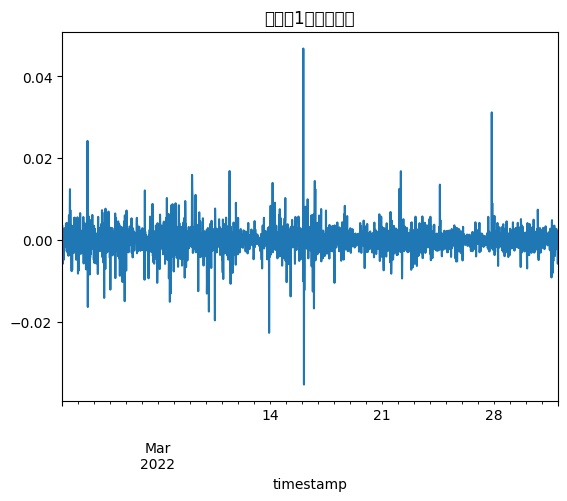

In [48]:
# 対数価格系列に対する1階の次差分
plt.title("終値の1次差分系列")
df["diff_log_close"].plot()

if adf_test(df["diff_log_close"], do_print=True):
    print("1次差分系列は定常である")
else:
    print("1次差分系列は非定常である")

Results of Dickey-Fuller Examination:
Test Statistic                   -1.000443
p-value                           0.753103
#Lags Used                        4.000000
Number of Observations Used    2970.000000
dtype: float64
1次差分系列は非定常である


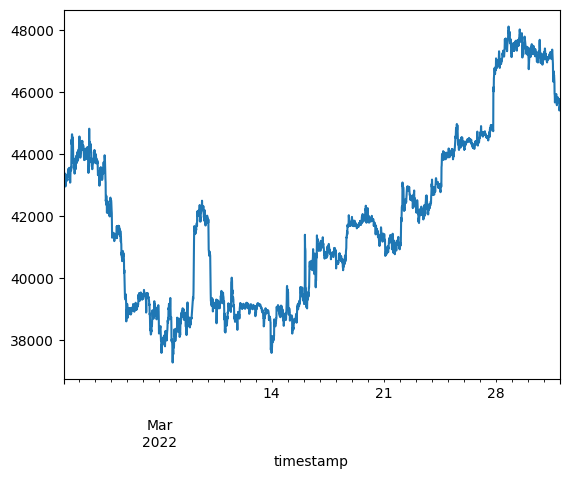

In [49]:


df["cl"].plot()

if adf_test(df["cl"], do_print=True):
    print("1次差分系列は定常である")
else:
    print("1次差分系列は非定常である")

In [50]:
# 回帰モデルの導入
from sklearn.linear_model import LinearRegression

In [51]:
# データと予測対象になるラベルの用意
Xy = df[["diff_log_close"]]
# 予測対象として,diff_log_closeの1ステップ先の値を設定しています.
Xy["y"] = df["diff_log_close"].shift(-1)
Xy.dropna(inplace=True)
Xy.head()

,diff_log_close,y
timestamp,,
2022-03-01 00:15:00,0.000000,0.003625
2022-03-01 00:30:00,0.003625,0.000574
2022-03-01 00:45:00,0.000574,-0.005884
2022-03-01 01:00:00,-0.005884,-0.000069
2022-03-01 01:15:00,-0.000069,0.002526


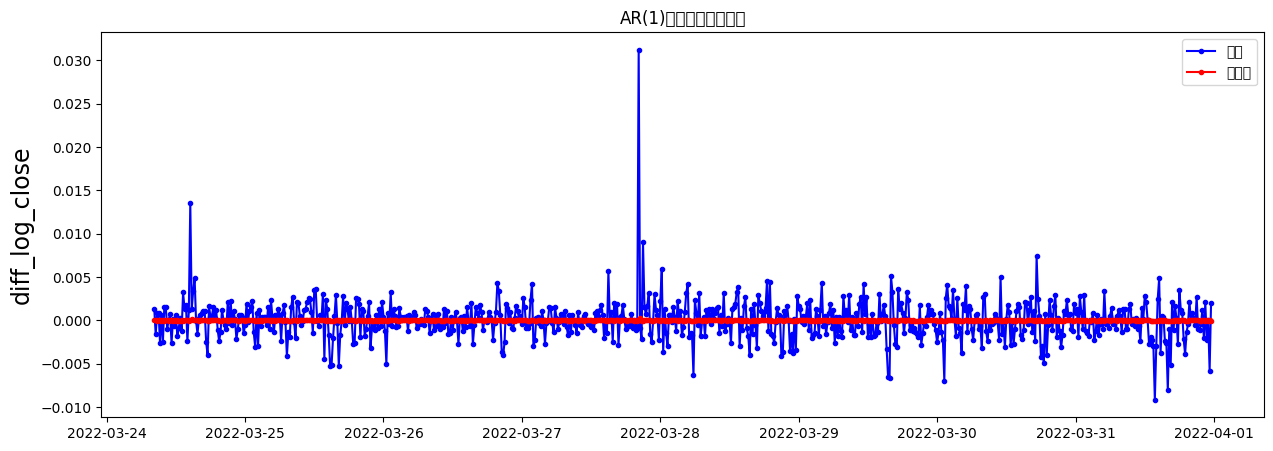

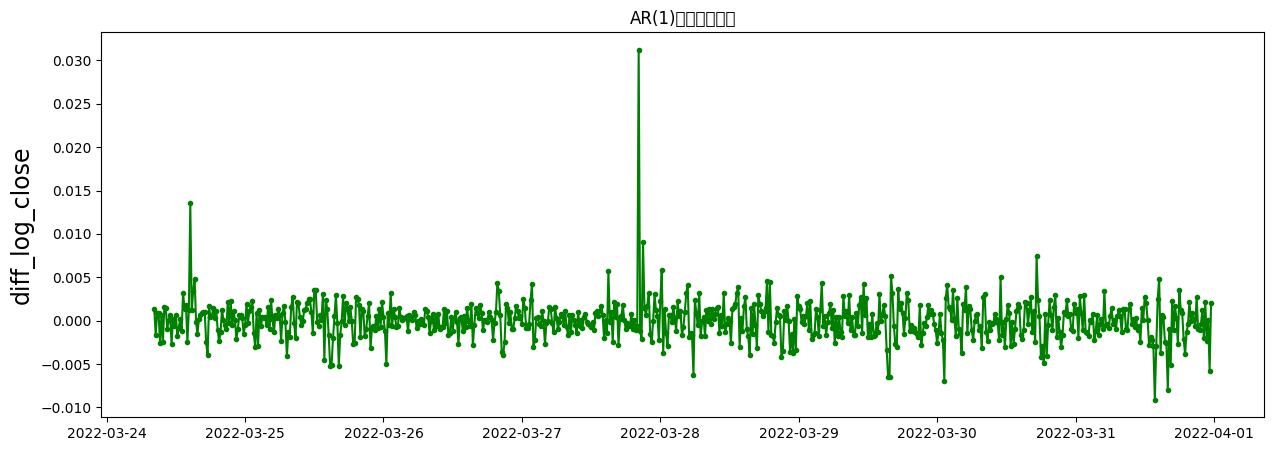

In [56]:
# trainとvalidationの分割
trainX, trainy, valX, valy = timeseries_train_val_split(Xy, target="y")

# AR(1)モデルの設定とfitting
lr = LinearRegression()
lr.fit(trainX[["diff_log_close"]], trainy)
pred = lr.predict(valX[["diff_log_close"]])

# 結果のプロット
plot_result(target=valy, pred=pred, title="AR(1)モデルの予測結果", ylabel="diff_log_close")
plot_resid(valy, pred, title="AR(1)モデルの誤差", ylabel="diff_log_close")

In [53]:
# 評価
eval_direction(valy, pred)


accuracy 0.49591280653950953


In [ ]:
# データとラベルの用意

# 過去10本分の平均と標準偏差を用いて標準化を実施(未来情報を参照しないように標準化)
df["scaled_log_open"] = (df["log_open"] - df["log_open"].rolling(10).mean()) / df["log_open"].rolling(10).std()
df["scaled_log_high"] = (df["log_high"] - df["log_high"].rolling(10).mean()) / df["log_high"].rolling(10).std()
df["scaled_log_low"] = (df["log_low"] - df["log_low"].rolling(10).mean()) / df["log_low"].rolling(10).std()
df["scaled_log_close"] = (df["log_close"] - df["log_close"].rolling(10).mean()) / df["log_close"].rolling(10).std()

Xy = df[["scaled_log_open", "scaled_log_high", "scaled_log_low", "scaled_log_close", "diff_log_close"]]
Xy["y"] = df["diff_log_close"].shift(-1)
Xy.dropna(inplace=True)
Xy.head()

,scaled_log_open,scaled_log_high,scaled_log_low,scaled_log_close,diff_log_close,y
timestamp,,,,,,
2022-03-01 02:30:00,-1.671618,-1.543691,-1.554960,-1.046335,0.001439,0.001228
2022-03-01 02:45:00,-1.046707,-1.099313,-0.704002,-0.608659,0.001228,-0.004818
2022-03-01 03:00:00,-0.608783,-0.899402,-1.458336,-1.486167,-0.004818,0.002255
2022-03-01 03:15:00,-1.486460,-1.306092,-1.523363,-0.818815,0.002255,-0.000070
2022-03-01 03:30:00,-0.816003,-1.051518,-0.620609,-0.682855,-0.000070,0.002169


<Axes: title={'center': '標準化した対数終値系列'}, xlabel='timestamp', ylabel='scaled_log_close'>

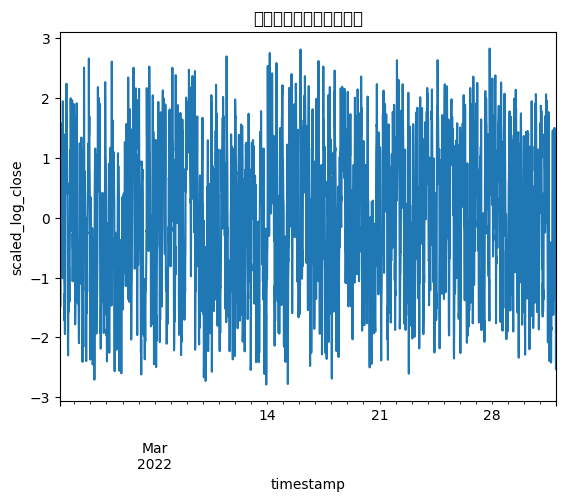

In [58]:
# 標準化の結果確認
plt.title("標準化した対数終値系列")
plt.ylabel("scaled_log_close")
Xy["scaled_log_close"].plot()